# Eksplorasi Data Iris (Data Understanding)

Setelah memahami konsep dasar dari statistik deskriptif, langkah selanjutnya adalah menerapkannya secara langsung pada dataset nyata. Pada tahap ini, kita akan melakukan *Data Understanding* atau pemahaman data terhadap salah satu dataset paling ikonik dalam dunia *Data Mining*, yaitu **Dataset Bunga Iris**.

Eksplorasi ini sangat penting agar kita tahu persis karakteristik, bentuk, dan kualitas dari data yang akan kita olah sebelum masuk ke tahap pembuatan model algoritma (seperti klasifikasi).

---

## 1. Integrasi dan Sumber Data

Sebagai seorang *Data Scientist* atau *Data Engineer*, data jarang sekali datang hanya dari satu file yang rapi. Dalam proyek ini, data bunga Iris merupakan hasil ekstraksi dari beberapa sumber yang berbeda untuk memastikan validitasnya:

1. **Database Relasional (RDBMS):** Sebagian besar data transaksional dan historis ditarik dari **PostgreSQL** dan **MySQL** menggunakan koneksi engine (seperti `SQLAlchemy`).
2. **File Pertukaran Data:** Untuk keperluan analisis lokal di Jupyter Notebook, data dari database tersebut diekspor ke dalam format **CSV** (`IRIS.csv`) dan **JSON** agar lebih ringan untuk diproses.
3. **Web Statis:** Informasi tambahan mengenai karakteristik biologis bunga divalidasi silang menggunakan referensi dari halaman web statis botani.

---

## 2. Deskripsi Karakteristik Dataset (Overview)

Dataset Iris bukanlah dataset yang asal dibuat. Data ini berisi ukuran fisik dari berbagai sampel bunga. Berikut adalah rincian anatomi dari dataset ini:

* **Total Observasi (Jumlah Data):** Terdapat **150 baris data** yang mewakili 150 sampel bunga yang berbeda. Setiap sampel diberikan **ID dari 1 hingga 150**.
* **Distribusi Kelas (Target Klasifikasi):** Data ini diklasifikasikan ke dalam **3 spesies utama**, yang pembagiannya sangat seimbang (*perfectly balanced*), yaitu:
  1. `Iris-setosa` (50 data)
  2. `Iris-versicolor` (50 data)
  3. `Iris-virginica` (50 data)
* **Jumlah Fitur (Variabel Input):** Terdapat **4 fitur bertipe numerik (Float)** yang digunakan untuk mengukur ciri-ciri fisik bunga, yaitu:
  1. `sepal_length` : Panjang kelopak bunga (dalam cm)
  2. `sepal_width` : Lebar kelopak bunga (dalam cm)
  3. `petal_length` : Panjang mahkota bunga (dalam cm)
  4. `petal_width` : Lebar mahkota bunga (dalam cm)

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat data dari file CSV lokal hasil integrasi database
df_iris = pd.read_csv('IRIS.csv')

# Menampilkan cuplikan data teratas untuk memastikan data masuk dengan benar
print("Cuplikan 5 Data Teratas Dataset Iris:")
display(df_iris.head())

Cuplikan 5 Data Teratas Dataset Iris:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Identifikasi Kualitas Data (Data Quality Check)

Kualitas data akan sangat menentukan seberapa akurat algoritma kita nantinya (*Garbage In, Garbage Out*). Ada dua hal yang wajib kita cek di sini: **Kekosongan Data** dan **Anomali Data**.

### **A. Pengecekan Missing Values (Data yang Hilang)**
*Missing Values* terjadi ketika ada baris atau kolom yang tidak memiliki nilai (kosong / `NaN`). Jika data ini dibiarkan, perhitungan jarak (seperti *Euclidean* atau *Manhattan*) akan mengalami *error*.
Jika ada data yang hilang, solusinya biasanya adalah membuang baris tersebut (Drop) atau mengisinya dengan nilai rata-rata (Imputasi). Mari kita periksa dataset kita.

In [10]:
# Pengecekan jumlah data yang kosong per kolom
missing_info = df_iris.isnull().sum()
print("Laporan Pengecekan Missing Values:\n")
print(missing_info)
print("\nKesimpulan: Tidak ada missing values (0 data kosong). Dataset ini sangat berkualitas.")

Laporan Pengecekan Missing Values:

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Kesimpulan: Tidak ada missing values (0 data kosong). Dataset ini sangat berkualitas.


### **B. Identifikasi Outlier (Pencilan Data)**
*Outlier* adalah titik data yang nilainya menyimpang secara ekstrem dari mayoritas data lainnya. Misalnya, jika rata-rata lebar kelopak adalah 3 cm, tapi ada satu bunga dengan lebar 8 cm, itu adalah outlier. 

Untuk mengidentifikasinya tanpa harus membaca data satu per satu, kita bisa menggunakan pendekatan visual, yaitu **Boxplot**. Titik-titik yang berada di luar "kumis" (whiskers) pada boxplot diindikasikan sebagai outlier secara statistik.

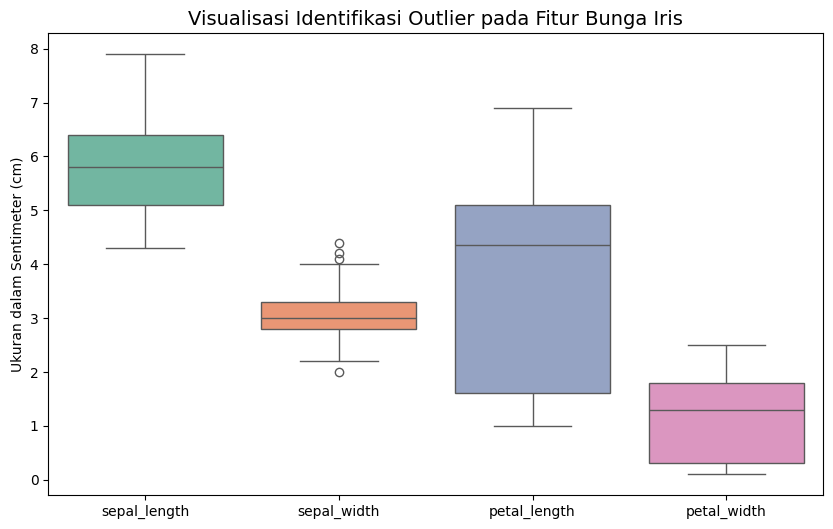

In [11]:
# Membuat visualisasi Boxplot untuk ke-4 fitur numerik
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_iris.drop('species', axis=1), palette="Set2")
plt.title("Visualisasi Identifikasi Outlier pada Fitur Bunga Iris", fontsize=14)
plt.ylabel("Ukuran dalam Sentimeter (cm)")
plt.show()

**Hasil Analisis Outlier:**
Berdasarkan grafik di atas, fitur `sepal_width` (lebar kelopak) memiliki beberapa titik pencilan di bagian atas dan bawah. Ini menunjukkan ada beberapa bunga yang kelopaknya sedikit lebih lebar atau lebih sempit dari biasanya. Namun, mengingat ini adalah variasi alamiah dari tumbuhan, data pencilan ini masih dianggap valid dan tidak perlu dihapus.

---

## 4. Statistik Deskriptif dari Setiap Kelas

Karena tujuan akhir kita adalah membedakan ketiga jenis bunga ini, kita harus melihat karakteristik unik dari masing-masing kelas. Kita akan menghitung **Rata-rata (Mean)**, **Standar Deviasi (Std)**, **Nilai Minimum/Maksimum**, dan **Kuartil (25%, 50%, 75%)** untuk *Setosa*, *Versicolor*, dan *Virginica*.

In [12]:
# Memecah dan menampilkan statistik deskriptif khusus per spesies
spesies_list = df_iris['species'].unique()

for spesies in spesies_list:
    print(f"\n{'='*40}")
    print(f"Statistik Deskriptif untuk Kelas: {spesies}")
    print(f"{'='*40}")
    # Memfilter data berdasarkan spesies, lalu menghitung statistiknya
    stats = df_iris[df_iris['species'] == spesies].describe().T
    display(stats)


Statistik Deskriptif untuk Kelas: Iris-setosa


,count,mean,std,min,25%,50%,75%,max
sepal_length,50.0,5.006,0.352490,4.3,4.800,5.0,5.200,5.8
sepal_width,50.0,3.418,0.381024,2.3,3.125,3.4,3.675,4.4
petal_length,50.0,1.464,0.173511,1.0,1.400,1.5,1.575,1.9
petal_width,50.0,0.244,0.107210,0.1,0.200,0.2,0.300,0.6



Statistik Deskriptif untuk Kelas: Iris-versicolor


,count,mean,std,min,25%,50%,75%,max
sepal_length,50.0,5.936,0.516171,4.9,5.600,5.90,6.3,7.0
sepal_width,50.0,2.770,0.313798,2.0,2.525,2.80,3.0,3.4
petal_length,50.0,4.260,0.469911,3.0,4.000,4.35,4.6,5.1
petal_width,50.0,1.326,0.197753,1.0,1.200,1.30,1.5,1.8



Statistik Deskriptif untuk Kelas: Iris-virginica


,count,mean,std,min,25%,50%,75%,max
sepal_length,50.0,6.588,0.635880,4.9,6.225,6.50,6.900,7.9
sepal_width,50.0,2.974,0.322497,2.2,2.800,3.00,3.175,3.8
petal_length,50.0,5.552,0.551895,4.5,5.100,5.55,5.875,6.9
petal_width,50.0,2.026,0.274650,1.4,1.800,2.00,2.300,2.5


### **Interpretasi Hasil Statistik**
Berdasarkan tabel perhitungan statistik di atas, kita bisa menarik beberapa insight berharga:
1. **Iris-Setosa:** Memiliki rata-rata ukuran mahkota (`petal_length` dan `petal_width`) yang paling kecil dibandingkan yang lain. Artinya, Setosa adalah bunga yang ukurannya relatif mungil.
2. **Iris-Virginica:** Memiliki rata-rata ukuran mahkota yang paling besar dan panjang.
3. **Iris-Versicolor:** Memiliki ukuran yang berada di tengah-tengah antara Setosa dan Virginica.

Dengan perbedaan statistik yang cukup mencolok ini (terutama pada fitur *petal*), algoritma klasifikasi nantinya akan lebih mudah menarik garis batas antar kelas.